In [1]:
# part1_data.py
import os
import math
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

In [2]:
# ----------------------------
# Reproducibility
# ----------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# a. Load the Tiny Shakespeare text

In [3]:
import requests

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)

text = response.text

# Save locally (so tokenizer can train from file)
with open("tinyshakespeare.txt", "w", encoding="utf-8") as f:
    f.write(text)

print("Dataset size:", len(text))
print(text[:300])

Dataset size: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


## b. Tokenization

In [4]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

# Initialize BPE tokenizer
tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))

# Pre-tokenization (split on whitespace)
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

# Trainer (vocab ≤ 500)
trainer = trainers.BpeTrainer(
    vocab_size=500,
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
)

# Train tokenizer
tokenizer.train(["tinyshakespeare.txt"], trainer)

# Encode full dataset
encoded = tokenizer.encode(text)
token_ids = encoded.ids

print("Vocab size:", tokenizer.get_vocab_size())
print("First tokens:", token_ids[:20])

Vocab size: 500
First tokens: [407, 17, 93, 49, 66, 75, 12, 396, 283, 116, 300, 101, 110, 424, 46, 138, 131, 8, 395, 81]


## c. Sequence formatting

In [5]:
context_length = 50
stride = 1  # overlapping

inputs = []
targets = []

for i in range(0, len(token_ids) - context_length):
    x = token_ids[i : i + context_length]
    y = token_ids[i + 1 : i + context_length + 1]

    inputs.append(x)
    targets.append(y)

import numpy as np
inputs = np.array(inputs)
targets = np.array(targets)

print("Inputs shape:", inputs.shape)
print("Targets shape:", targets.shape)

Inputs shape: (448079, 50)
Targets shape: (448079, 50)


In [6]:
# Check the output
print(inputs[0][:10])
print(targets[0][:10])

[407  17  93  49  66  75  12 396 283 116]
[ 17  93  49  66  75  12 396 283 116 300]


## d. Data split Use 80% for training and 20% for validation, no test set is needed this time

In [7]:
split_idx = int(0.8 * len(inputs))

train_inputs = inputs[:split_idx]
train_targets = targets[:split_idx]

val_inputs = inputs[split_idx:]
val_targets = targets[split_idx:]

print("Train size:", len(train_inputs))
print("Val size:", len(val_inputs))

Train size: 358463
Val size: 89616


In [8]:
# Load the data
class ShakespeareDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = torch.tensor(inputs, dtype=torch.long)
        self.targets = torch.tensor(targets, dtype=torch.long)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

# build datasets
train_dataset = ShakespeareDataset(train_inputs, train_targets)
val_dataset = ShakespeareDataset(val_inputs, val_targets)

# build dataloaders
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

# quick check
xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)

torch.Size([32, 50]) torch.Size([32, 50])


## e. Token embedding

In [9]:
def forward(self, x):
    x = self.token_embedding(x)   # (B, T, C)
    x = self.pos_encoding(x)      # add position

    x = self.blocks(x)

    x = self.norm(x)
    logits = self.head(x)

    return logits

## Transformer

In [11]:
import torch
import torch.nn as nn
import math

# -----------------------------
# Positional Encoding
# -----------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, dim, max_len=500):
        super().__init__()

        pe = torch.zeros(max_len, dim)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(torch.arange(0, dim, 2) * (-math.log(10000.0) / dim))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, dim)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


# -----------------------------
# Self-Attention (causal)
# -----------------------------
class SelfAttention(nn.Module):
    def __init__(self, embed_dim, max_len=500, dropout=0.1):
        super().__init__()

        self.q = nn.Linear(embed_dim, embed_dim)
        self.k = nn.Linear(embed_dim, embed_dim)
        self.v = nn.Linear(embed_dim, embed_dim)
        self.out = nn.Linear(embed_dim, embed_dim)

        self.dropout = nn.Dropout(dropout)

        # Precompute causal mask
        self.register_buffer(
            "mask",
            torch.tril(torch.ones(max_len, max_len))
        )

    def forward(self, x):
        B, T, C = x.shape

        Q = self.q(x)
        K = self.k(x)
        V = self.v(x)

        d_k = Q.size(-1)

        attn = (Q @ K.transpose(-2, -1)) / math.sqrt(d_k)

        attn = attn.masked_fill(self.mask[:T, :T] == 0, float("-inf"))

        attn = torch.softmax(attn, dim=-1)
        attn = self.dropout(attn)

        out = attn @ V
        out = self.out(out)
        out = self.dropout(out)

        return out


# -----------------------------
# RMSNorm
# -----------------------------
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-8):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        norm = x.pow(2).mean(-1, keepdim=True)
        x = x / torch.sqrt(norm + self.eps)
        return self.scale * x


# -----------------------------
# Feed Forward
# -----------------------------
class FeedForward(nn.Module):
    def __init__(self, dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 4 * dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(4 * dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


# -----------------------------
# Transformer Block
# -----------------------------
class TransformerBlock(nn.Module):
    def __init__(self, dim, max_len=500):
        super().__init__()

        self.norm1 = RMSNorm(dim)
        self.norm2 = RMSNorm(dim)

        self.attn = SelfAttention(dim, max_len=max_len)
        self.ffn = FeedForward(dim)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))  # attention + residual
        x = x + self.ffn(self.norm2(x))   # ffn + residual
        return x


# -----------------------------
# Tiny Transformer
# -----------------------------
class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, dim=64, num_layers=2, max_len=500):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, dim)
        self.pos_encoding = PositionalEncoding(dim, max_len=max_len)

        self.blocks = nn.Sequential(*[
            TransformerBlock(dim, max_len=max_len)
            for _ in range(num_layers)
        ])

        self.norm = RMSNorm(dim)
        self.head = nn.Linear(dim, vocab_size)

    def forward(self, x):
        x = self.token_embedding(x)     # (B, T, C)
        x = self.pos_encoding(x)

        x = self.blocks(x)

        x = self.norm(x)
        logits = self.head(x)           # (B, T, vocab)

        return logits


# -----------------------------
# Test run
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

model = TinyTransformer(vocab_size=500, dim=64).to(device)

x = torch.randint(0, 500, (4, 50)).to(device)
logits = model(x)

print(logits.shape)  # should be (4, 50, 500)

torch.Size([4, 50, 500])


## Training

In [15]:
results = {}

for lr in learning_rates:
    print(f"\nTraining with lr = {lr}")

    model = TinyTransformer(vocab_size=500, dim=64).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []

    for epoch in range(3):
        # ---- TRAIN ----
        model.train()
        total_train = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)

            B, T, V = logits.shape
            loss = criterion(
                logits.view(B*T, V),
                yb.view(B*T)
            )

            loss.backward()
            optimizer.step()

            total_train += loss.item()

        avg_train = total_train / len(train_loader)
        train_losses.append(avg_train)

        # ---- VALIDATION ----
        model.eval()
        total_val = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)

                logits = model(xb)
                B, T, V = logits.shape

                loss = criterion(
                    logits.view(B*T, V),
                    yb.view(B*T)
                )

                total_val += loss.item()

        avg_val = total_val / len(val_loader)
        val_losses.append(avg_val)

        print(f"Epoch {epoch+1}: Train {avg_train:.4f}, Val {avg_val:.4f}")

    results[lr] = {
        "train": train_losses,
        "val": val_losses
    }


Training with lr = 0.0001
Epoch 1: Train 4.4316, Val 4.3723
Epoch 2: Train 3.9554, Val 4.2774
Epoch 3: Train 3.8247, Val 4.2288

Training with lr = 0.0003
Epoch 1: Train 4.0688, Val 4.2405
Epoch 2: Train 3.6958, Val 4.1470
Epoch 3: Train 3.5888, Val 4.0940

Training with lr = 0.001
Epoch 1: Train 3.7858, Val 4.1122
Epoch 2: Train 3.5059, Val 4.0815
Epoch 3: Train 3.4356, Val 4.0719


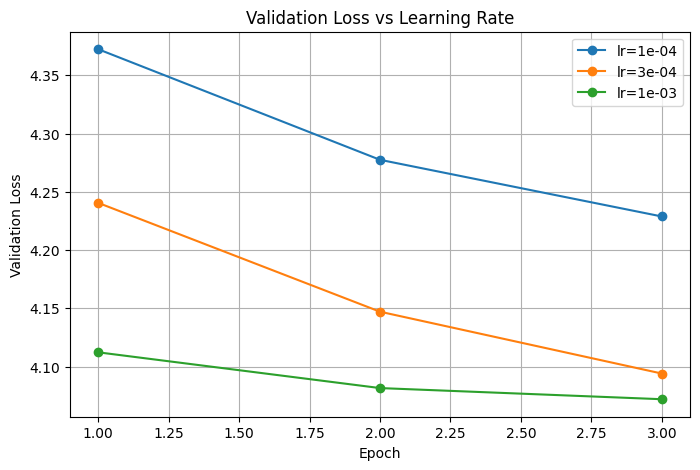

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for lr, data in results.items():
    epochs = range(1, len(data["val"]) + 1)
    plt.plot(epochs, data["val"], marker="o", label=f"lr={lr:.0e}")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Learning Rate")
plt.legend()
plt.grid(True)

plt.show()



#### lr = 1e-3 → validation error = 4.0719 ✅ best

## Do early stopping on lr = 1e-3

In [20]:
import torch.optim as optim
import copy

model = TinyTransformer(vocab_size=500, dim=64).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

max_epochs = 15
patience = 2

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None
counter = 0

for epoch in range(max_epochs):
    # ---- TRAIN ----
    model.train()
    total_train = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)

        B, T, V = logits.shape
        loss = criterion(logits.view(B * T, V), yb.view(B * T))

        loss.backward()
        optimizer.step()

        total_train += loss.item()

    avg_train = total_train / len(train_loader)
    train_losses.append(avg_train)

    # ---- VALIDATION ----
    model.eval()
    total_val = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)
            B, T, V = logits.shape
            loss = criterion(logits.view(B * T, V), yb.view(B * T))

            total_val += loss.item()

    avg_val = total_val / len(val_loader)
    val_losses.append(avg_val)

    print(f"Epoch {epoch+1}: Train {avg_train:.4f}, Val {avg_val:.4f}")

    # ---- EARLY STOPPING ----
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_model_state = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 1: Train 3.7969, Val 4.1256
Epoch 2: Train 3.5119, Val 4.0677
Epoch 3: Train 3.4340, Val 4.0620
Epoch 4: Train 3.3924, Val 4.0479
Epoch 5: Train 3.3654, Val 4.0234
Epoch 6: Train 3.3464, Val 4.0264
Epoch 7: Train 3.3322, Val 4.0215
Epoch 8: Train 3.3210, Val 4.0188
Epoch 9: Train 3.3122, Val 4.0252
Epoch 10: Train 3.3048, Val 4.0211
Early stopping triggered at epoch 10
Best validation loss: 4.0188


## perplexity

In [31]:
ppl = math.exp(best_val_loss)
print("Best perplexity:", ppl)

Best perplexity: 55.633343862146816


## Loss Curve

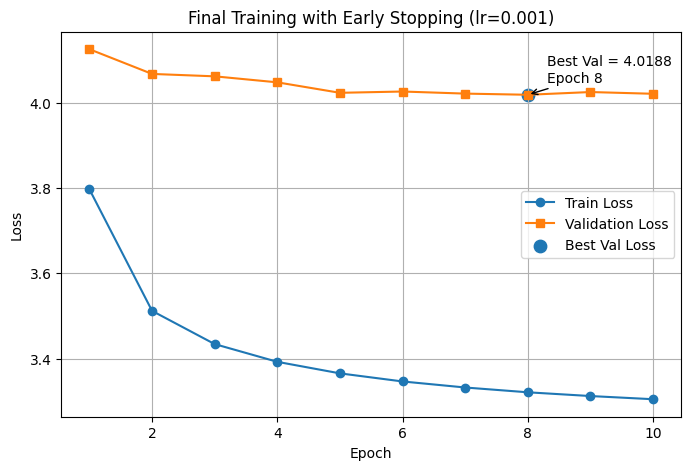

In [69]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

best_epoch = val_losses.index(min(val_losses)) + 1
best_val = min(val_losses)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o", label="Train Loss")
plt.plot(epochs, val_losses, marker="s", label="Validation Loss")

# mark best validation point
plt.scatter(best_epoch, best_val, s=80, label="Best Val Loss")
plt.annotate(f"Best Val = {best_val:.4f}\nEpoch {best_epoch}",
             xy=(best_epoch, best_val),
             xytext=(best_epoch + 0.3, best_val + 0.03),
             arrowprops=dict(arrowstyle="->"))

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Training with Early Stopping (lr=0.001)")
plt.legend()
plt.grid(True)
plt.show()

### Using a learning rate of 0.001, the model achieved the lowest validation loss of 4.0188 at epoch 8. After this point, validation performance plateaued, and early stopping was triggered at epoch 10 with a patience of 2. This indicates that the model converged efficiently without significant overfitting.

### Use lr = 1e-03 to create attention heatmap

In [61]:
import torch
import torch.nn as nn
import torch.optim as optim

model = TinyTransformer(vocab_size=500, dim=64).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

max_epochs = 3
best_val_loss = float("inf")

for epoch in range(max_epochs):
    # ---- TRAIN ----
    model.train()
    total_train = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)

        B, T, V = logits.shape
        loss = criterion(logits.view(B*T, V), yb.view(B*T))

        loss.backward()
        optimizer.step()

        total_train += loss.item()

    avg_train = total_train / len(train_loader)

    # ---- VALIDATION ----
    model.eval()
    total_val = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)
            B, T, V = logits.shape
            loss = criterion(logits.view(B*T, V), yb.view(B*T))

            total_val += loss.item()

    avg_val = total_val / len(val_loader)

    print(f"Epoch {epoch+1}: Train {avg_train:.4f}, Val {avg_val:.4f}")

    # SAVE EVERY EPOCH
    torch.save(model.state_dict(), f"lr_1e3_epoch_{epoch+1}.pt")

    # SAVE BEST
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), "lr_1e3_best.pt")

Epoch 1: Train 3.7995, Val 4.1659
Epoch 2: Train 3.5204, Val 4.1257
Epoch 3: Train 3.4434, Val 4.0968


In [68]:
model = TinyTransformer(vocab_size=500, dim=64).to(device)
model.load_state_dict(torch.load("lr_1e3_best.pt", map_location=device))
model.eval()

TinyTransformer(
  (token_embedding): Embedding(500, 64)
  (pos_encoding): PositionalEncoding()
  (blocks): Sequential(
    (0): TransformerBlock(
      (norm1): RMSNorm()
      (norm2): RMSNorm()
      (attn): SelfAttention(
        (q): Linear(in_features=64, out_features=64, bias=True)
        (k): Linear(in_features=64, out_features=64, bias=True)
        (v): Linear(in_features=64, out_features=64, bias=True)
        (out): Linear(in_features=64, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=64, out_features=256, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=256, out_features=64, bias=True)
          (4): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): RMSNorm()
      (norm2): RMSNorm()
      (attn): SelfAttention(
        (q): Linear(in_feature

## Heatmap

In [62]:
import torch
import math
import matplotlib.pyplot as plt

def get_attention_from_block_no_patch(model, xb, block_idx=0):
    model.eval()
    with torch.no_grad():
        # embeddings + positions
        x = model.token_embedding(xb)
        x = model.pos_encoding(x)

        # pass through earlier blocks normally
        for i in range(block_idx):
            x = model.blocks[i](x)

        block = model.blocks[block_idx]

        # same input the attention module sees
        h = block.norm1(x)

        # manually reproduce attention using trained q/k/v layers
        Q = block.attn.q(h)
        K = block.attn.k(h)
        V = block.attn.v(h)

        B, T, C = Q.shape
        attn = Q @ K.transpose(-2, -1) / math.sqrt(C)

        mask = torch.tril(torch.ones(T, T, device=xb.device))
        attn = attn.masked_fill(mask == 0, float("-inf"))
        attn = torch.softmax(attn, dim=-1)

    return attn
def plot_multi_sequence_block_attention_no_patch(model, val_loader, tokenizer, max_tokens=15):
    xb, yb = next(iter(val_loader))
    xb = xb.to(device)

    seq_indices = [0, 1]
    block_indices = [0, 1]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    for row, seq_idx in enumerate(seq_indices):
        for col, block_idx in enumerate(block_indices):
            attn = get_attention_from_block_no_patch(model, xb, block_idx=block_idx)
            attn_matrix = attn[seq_idx][:max_tokens, :max_tokens].cpu().numpy()

            token_ids = xb[seq_idx][:max_tokens].cpu().tolist()
            tokens = tokenizer.encode(tokenizer.decode(token_ids)).tokens
            n = min(len(tokens), attn_matrix.shape[0])
            tokens = tokens[:n]
            attn_matrix = attn_matrix[:n, :n]

            ax = axes[row, col]
            ax.imshow(attn_matrix, cmap="hot")
            ax.set_title(f"Seq {seq_idx+1}, Block {block_idx+1}")
            ax.set_xticks(range(n))
            ax.set_yticks(range(n))
            ax.set_xticklabels(tokens, rotation=90, fontsize=8)
            ax.set_yticklabels(tokens, fontsize=8)
            ax.set_xlabel("Key tokens")
            ax.set_ylabel("Query tokens")

    plt.tight_layout()
    plt.savefig("multi_sequence_block_attention.png", dpi=300, bbox_inches="tight")
    plt.show()


def plot_attention_across_epochs_no_patch(epoch_paths, val_loader, tokenizer, seq_idx=0, block_idx=0, max_tokens=15):
    xb, yb = next(iter(val_loader))
    xb = xb.to(device)

    token_ids = xb[seq_idx][:max_tokens].cpu().tolist()
    tokens = tokenizer.encode(tokenizer.decode(token_ids)).tokens

    fig, axes = plt.subplots(1, len(epoch_paths), figsize=(5 * len(epoch_paths), 4))
    if len(epoch_paths) == 1:
        axes = [axes]

    for ax, (label, path) in zip(axes, epoch_paths):
        temp_model = TinyTransformer(vocab_size=500, dim=64).to(device)
        temp_model.load_state_dict(torch.load(path, map_location=device))

        attn = get_attention_from_block_no_patch(temp_model, xb, block_idx=block_idx)
        attn_matrix = attn[seq_idx][:max_tokens, :max_tokens].cpu().numpy()

        n = min(len(tokens), attn_matrix.shape[0])
        tok = tokens[:n]
        attn_matrix = attn_matrix[:n, :n]

        ax.imshow(attn_matrix, cmap="hot")
        ax.set_title(label)
        ax.set_xticks(range(n))
        ax.set_yticks(range(n))
        ax.set_xticklabels(tok, rotation=90, fontsize=8)
        ax.set_yticklabels(tok, fontsize=8)
        ax.set_xlabel("Key tokens")
        ax.set_ylabel("Query tokens")

    plt.tight_layout()
    plt.savefig("attention_across_epochs.png", dpi=300, bbox_inches="tight")
    plt.show()


def plot_single_attention(model, val_loader, tokenizer, max_tokens=20):
    xb, _ = next(iter(val_loader))
    xb = xb.to(device)

    attn = get_attention_from_block_no_patch(model, xb, block_idx=1)

    attn_matrix = attn[0][:max_tokens, :max_tokens].cpu().numpy()

    token_ids = xb[0][:max_tokens].cpu().tolist()
    tokens = tokenizer.encode(tokenizer.decode(token_ids)).tokens

    n = min(len(tokens), attn_matrix.shape[0])
    tokens = tokens[:n]
    attn_matrix = attn_matrix[:n, :n]

    plt.figure(figsize=(8, 6))
    im = plt.imshow(attn_matrix, cmap="hot", vmin=0, vmax=1)

    plt.colorbar(im)
    plt.xticks(range(n), tokens, rotation=90)
    plt.yticks(range(n), tokens)

    plt.xlabel("Key Tokens")
    plt.ylabel("Query Tokens")
    plt.title("Attention Heatmap (First 20 Tokens)")

    plt.tight_layout()
    plt.savefig("attention_single.png", dpi=300)
    plt.show()



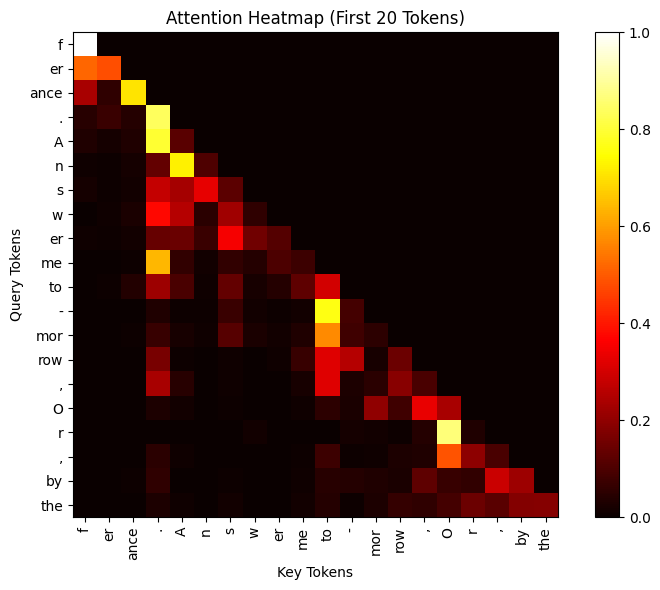

In [63]:
plot_single_attention(model, val_loader, tokenizer)

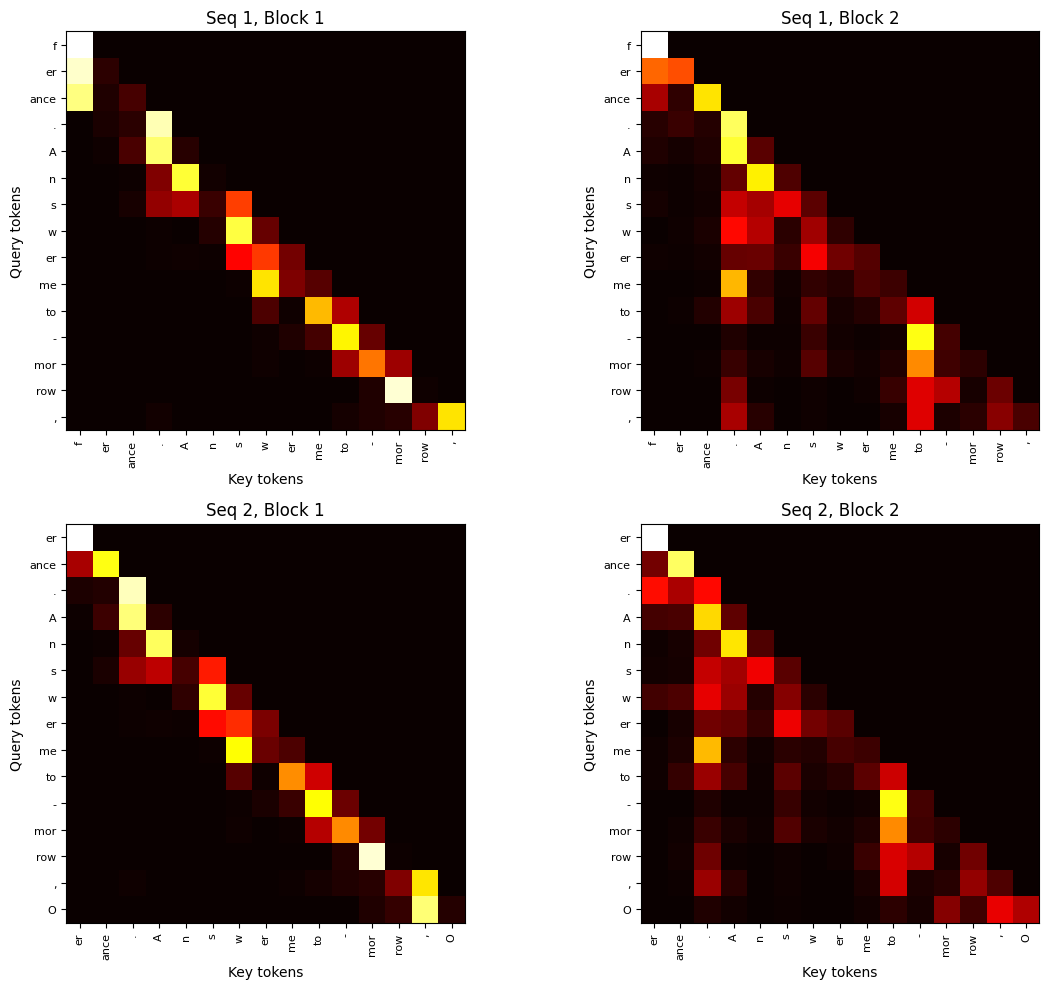

In [64]:
# 2×2 plot
plot_multi_sequence_block_attention_no_patch(
    model, val_loader, tokenizer, max_tokens=15
)

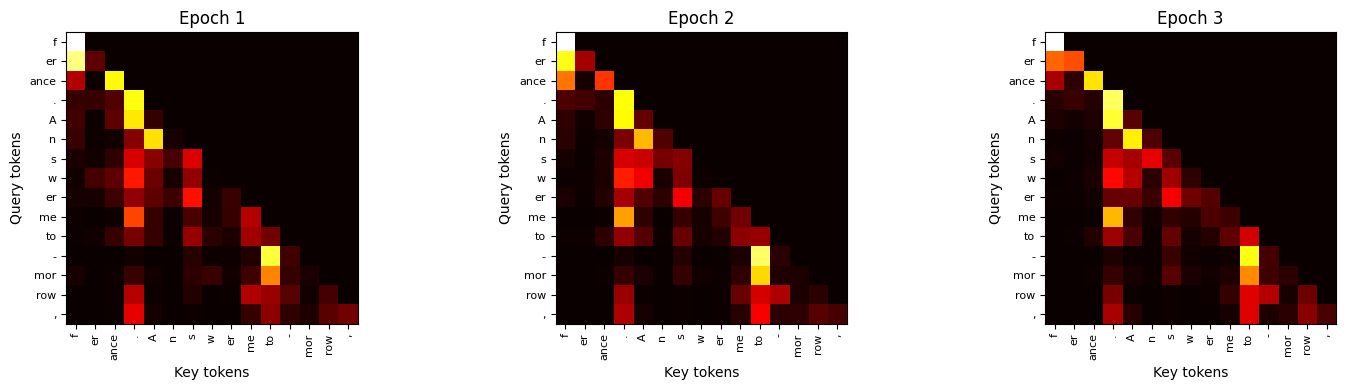

In [65]:
# 1x3 epoch comparison
epoch_paths = [
    ("Epoch 1", "lr_1e3_epoch_1.pt"),
    ("Epoch 2", "lr_1e3_epoch_2.pt"),
    ("Epoch 3", "lr_1e3_epoch_3.pt"),
]

plot_attention_across_epochs_no_patch(
    epoch_paths,
    val_loader,
    tokenizer,
    seq_idx=0,
    block_idx=1,
    max_tokens=15
)

In [66]:
import torch
import torch.nn.functional as F

def generate_text(model, tokenizer, prompt, max_new_tokens=50, temperature=1.0):
    model.eval()

    # encode prompt → tensor
    input_ids = tokenizer.encode(prompt).ids
    x = torch.tensor([input_ids], dtype=torch.long).to(device)

    for _ in range(max_new_tokens):
        logits = model(x)  # (1, T, vocab)

        # take last token prediction
        logits = logits[:, -1, :] / temperature

        probs = F.softmax(logits, dim=-1)

        # sample next token
        next_token = torch.multinomial(probs, num_samples=1)

        # append
        x = torch.cat([x, next_token], dim=1)

    # decode back to text
    output_ids = x[0].tolist()
    return tokenizer.decode(output_ids)

In [67]:
text = generate_text(
    model,
    tokenizer,
    prompt="To be or not to be",
    max_new_tokens=50,
    temperature=1.0
)

print(text)

To be or not to be g in as ion of the com m on A n ce ! w hy ' he hath d one . P a ul in the ac ter ' s word . W AR W IC K : U n mo ther ' s de ad he con j e
